# Local microenvironment variation around Aβ plaques (MERFISH)

The colorectal tutorial (`global_spatial_variation_tutorial.ipynb`) evaluates SAFFRON against a **global** 1-D gradient. This one instead evaluates against **local** microenvironment measures around amyloid-β plaques in an Alzheimer's disease MERFISH brain dataset.

## Using your own data

SAFFRON only needs one or more embeddings/SAE features in `.obsm` and a local measure in `.obs`. Replace the cell below with your own data, update `REPRESENTATIONS` to your own keys, and swap or omit `adata.uns["landmark_points"]` — a demo-specific marker array, not a SAFFRON requirement.

Three local measures (`τ`), computed over a 350 µm window (636 cells, 6 plaques) cropped from one tissue section for this demo — SAFFRON has no notion of "windows" itself and evaluates whatever cells are in your `AnnData`, so your own data need not be similarly cropped:
- `dam_score` — mean expression of the Keren-Shaul disease-associated-microglia (DAM) gene panel
- `micro_density` — microglia within 100 µm, as a density (cells / mm²)
- `distance_to_plaque` — negative distance to the nearest plaque (higher = closer)

`data/merfish_plaque.h5ad` bundles three precomputed SAE feature sets (`gene_sae_features`, `geneformer_sae_features`, `novae_finetune_sae_features`) and landmark point coordinates (plaque centroids, for this demo) in `adata.uns["landmark_points"]`.

In [1]:
import anndata
import numpy as np

from saffron import SAFFRON
from saffron.utils import plot_spatial_scatter

In [2]:
adata = anndata.read_h5ad("data/merfish_plaque.h5ad")  # or anndata.read_h5ad("your_data.h5ad")
adata

AnnData object with n_obs × n_vars = 636 × 1
    obs: 'dam_score', 'micro_density', 'plaque_distance', 'is_micro', 'cluster_coarse', 'distance_to_plaque'
    uns: 'landmark_points'
    obsm: 'gene_sae_features', 'geneformer_sae_features', 'novae_finetune_sae_features', 'spatial'

## Step 1: Evaluate Gene SAE vs. a representative SFM SAE, for each measure

For each measure, fit (loads instantly — the SAE features are already cached in `adata.obsm`) and evaluate both the Gene SAE and one SFM's SAE against it, over all 636 cells in the window.

In [3]:
# tau_key -> [(features_key, label), ...]: replace with your own .obs measures and .obsm keys
REPRESENTATIONS = {
    "dam_score":          [("gene_sae_features", "Gene SAE"), ("geneformer_sae_features", "Geneformer SAE")],
    "micro_density":      [("gene_sae_features", "Gene SAE"), ("novae_finetune_sae_features", "Novae FT SAE")],
    "distance_to_plaque": [("gene_sae_features", "Gene SAE"), ("novae_finetune_sae_features", "Novae FT SAE")],
}

results = {}
for tau_key, reps in REPRESENTATIONS.items():
    for rep_key, rep_label in reps:
        model = SAFFRON().fit(adata, features_key=rep_key)
        result = model.evaluate(adata, tau_key=tau_key, features_key=rep_key, restrict_support=False)
        results[(tau_key, rep_key)] = result
        print(f"{tau_key:18s} {rep_label:16s} best=#{result.correlation.best_feature:4d} rho={result.correlation.best_rho:+.3f}")

dam_score          Gene SAE         best=# 460 rho=+0.553


dam_score          Geneformer SAE   best=# 143 rho=-0.586
micro_density      Gene SAE         best=#  54 rho=+0.193
micro_density      Novae FT SAE     best=# 142 rho=+0.252


distance_to_plaque Gene SAE         best=# 288 rho=+0.216


distance_to_plaque Novae FT SAE     best=# 157 rho=+0.361


## Step 2: Spatial patterns

Reference measure alongside the best feature SAFFRON found for each representation. Red crosses
mark landmark points, i.e. plaque centroids for this demo (see the note on `markers` above).

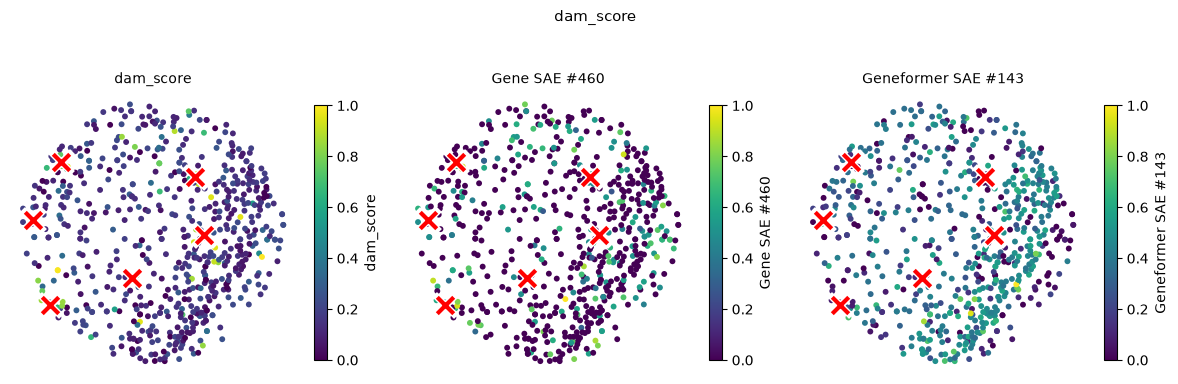

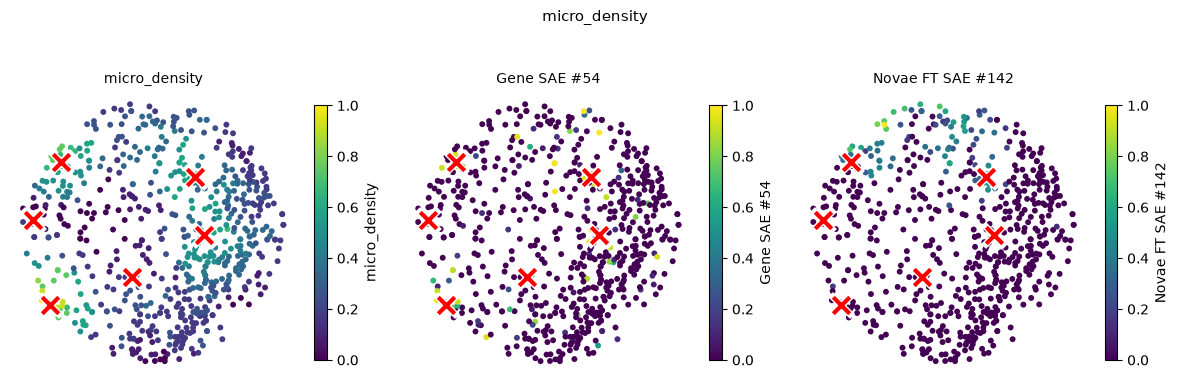

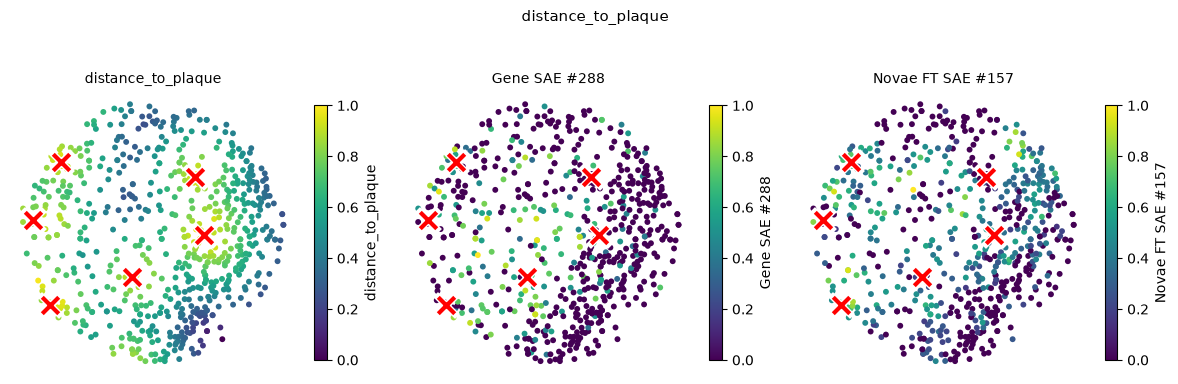

In [4]:
for tau_key, reps in REPRESENTATIONS.items():
    panels = {tau_key: adata.obs[tau_key].values}
    for rep_key, rep_label in reps:
        feat = results[(tau_key, rep_key)].correlation.best_feature
        panels[f"{rep_label} #{feat}"] = adata.obsm[rep_key][:, feat]
    plot_spatial_scatter(adata, panels, markers=adata.uns["landmark_points"], suptitle=tau_key)